<div style="background-color: white; color: #2F1192; padding: 15px; border-radius: 5px; font-family: 'Times New Roman', Times, serif;">
    <h2 style="color: #2F1192; margin: 0; font-size:30px; "><b>Task 1: Exploring and Visualizing a Simple Dataset</b></h2>
</div>

In [1]:
import matplotlib.pyplot as plt    #for creating charts
import pandas as pd                #for working with data tables               
import seaborn as sns              #for prettier charts
import numpy as np                 # for numbers and math

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# 1. Load the dataset
df = sns.load_dataset("iris")

In [3]:
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- First 5 Rows ---")
print(df.head())

--- Dataset Shape ---
(150, 5)

--- Column Names ---
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

--- First 5 Rows ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
print("\n--- Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Descriptive Statistics ---
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.9000

In [5]:
# How many flowers of each species?
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [17]:
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.facecolor": "#f8f9fa",  # Soft, off-white background
        "grid.color": "#222222",  # Crisp black grid lines
        "grid.linewidth": 0.8,  # Clean, thin lines
    },
)

# 2. Use your exact new custom colors
custom_colors = ["#AC96F3", "#2F1192", "#6A44E9"]
features = df.columns[:-1]  # Exclude the 'species' column

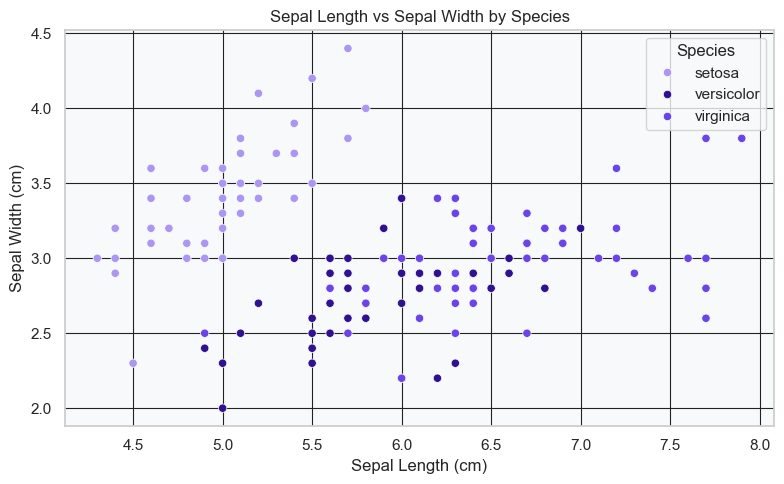

In [18]:
# Scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(8, 5))   # set chart size
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species',   # color by species
    palette=custom_colors
)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

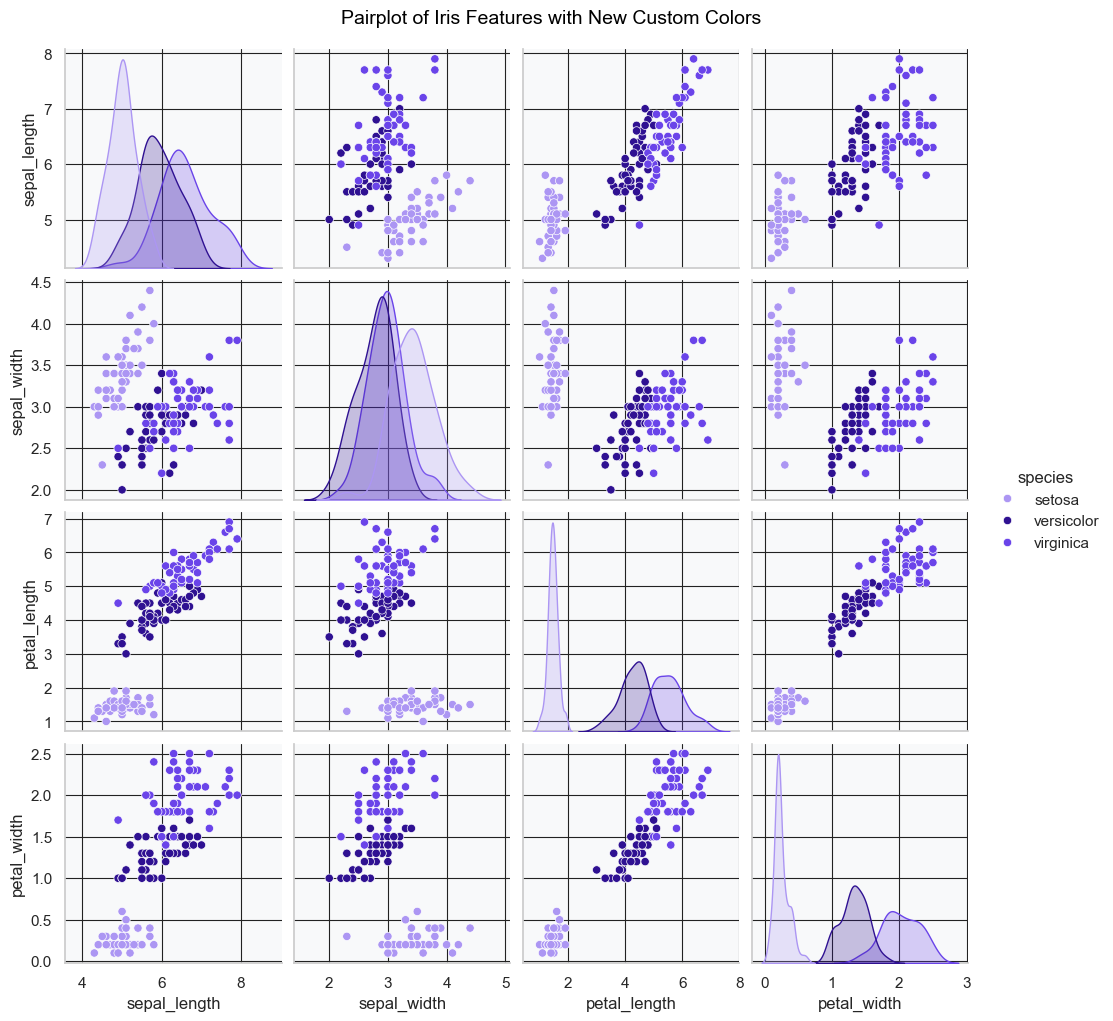

In [19]:
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue="species", palette=custom_colors)

plt.suptitle(
    "Pairplot of Iris Features with New Custom Colors",
    y=1.02,
    color="black",
    fontsize=14,
)
plt.show()

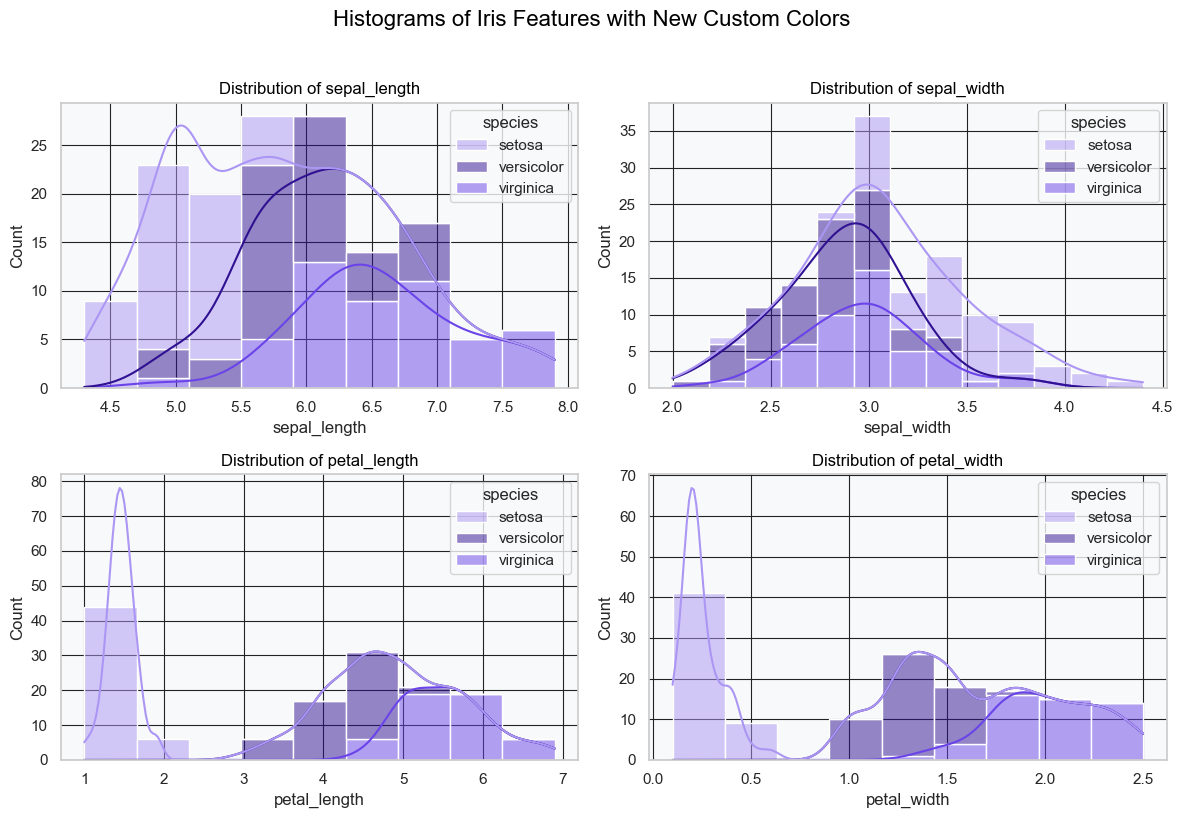

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        kde=True,
        ax=axes[i],
        palette=custom_colors,
        multiple="stack",
    )
    axes[i].set_title(f"Distribution of {feature}", color="black")

plt.suptitle(
    "Histograms of Iris Features with New Custom Colors",
    y=1.02,
    fontsize=16,
    color="black",
)
plt.tight_layout()
plt.show()

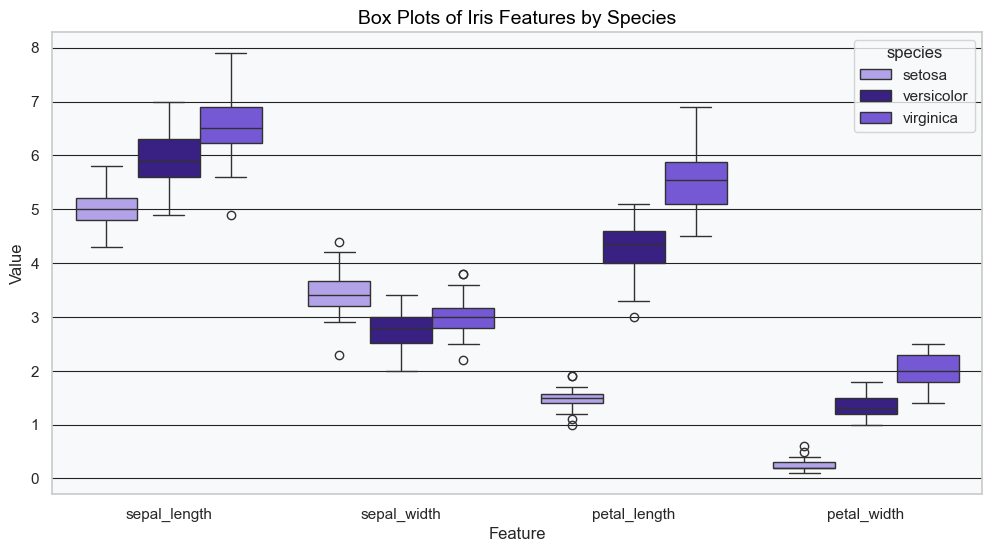

In [21]:
plt.figure(figsize=(12, 6))

# Melts the dataframe to a long-form format suitable for plotting side-by-side
df_melted = pd.melt(
    df, id_vars="species", value_vars=features, var_name="Feature", value_name="Value"
)

# Plotting the boxplot 
sns.boxplot(
    x="Feature", y="Value", hue="species", data=df_melted, palette=custom_colors
)
plt.title(
    "Box Plots of Iris Features by Species",
    color="black",
    fontsize=14,
)
plt.show()

## Task 1: Summary of Findings
- The dataset has 150 rows and 5 columns.
- There are 3 species: Setosa, Versicolor, and Virginica.
- Setosa has noticeably smaller petals than the other two species.
- The scatter plot shows Setosa is clearly separable from the others.
- No major outliers were found in the box plots.